In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [4]:
df = pd.read_csv(r"C:\Users\Dell\OneDrive - Sahana System Limited\Desktop\india-economy-etl\data\india_economy_clean.csv")
print("Data loaded successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Data loaded successfully!
Shape: (55, 4)

First 5 rows:


,year,fdi_inflow,gdp_growth_rate,inflation_rate
0,1970,0.072826,5.157230,5.092262
1,1971,0.070763,1.642930,3.079939
2,1972,0.024893,-0.553301,6.442097
3,1973,0.044330,3.295521,16.940816
4,1974,0.057241,1.185336,28.598734


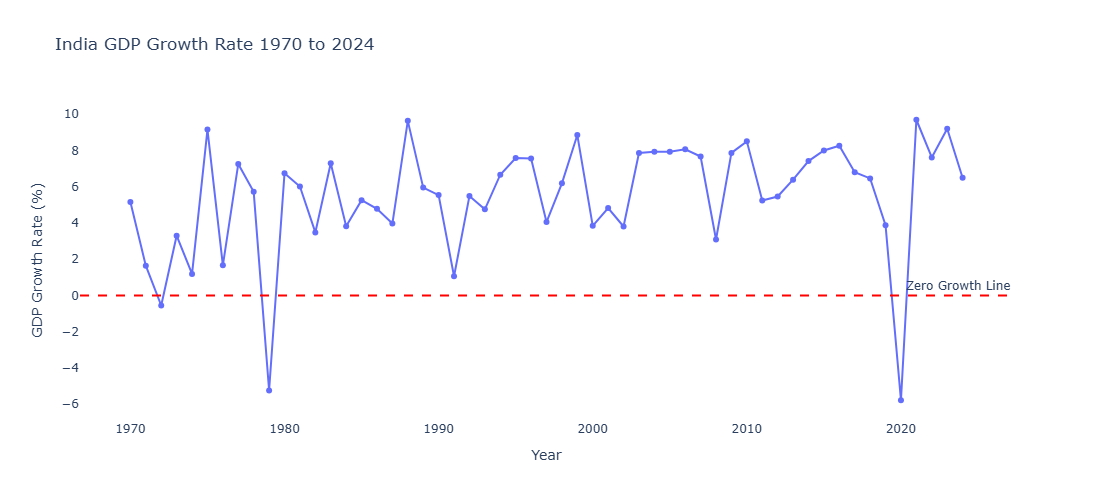

In [6]:
fig = px.line(
    df,
    x='year',
    y='gdp_growth_rate',
    title='India GDP Growth Rate 1970 to 2024',
    labels={'gdp_growth_rate': 'GDP Growth Rate (%)', 'year': 'Year'},
    markers=True
)

fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="red",
    annotation_text="Zero Growth Line"
)

fig.update_layout(
    hovermode='x unified',
    plot_bgcolor='white',
    width=900,
    height=500
)

fig.show()

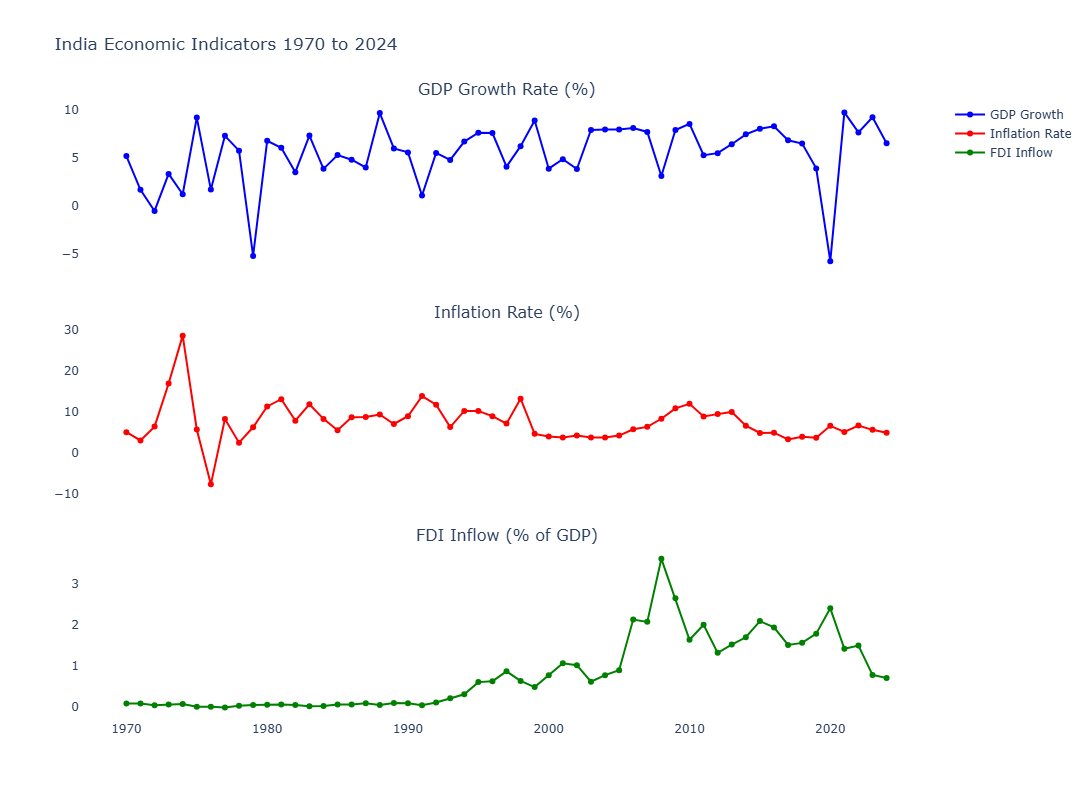

In [7]:
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=(
        'GDP Growth Rate (%)',
        'Inflation Rate (%)',
        'FDI Inflow (% of GDP)'
    ),
    shared_xaxes=True,
    vertical_spacing=0.08
)

fig.add_trace(
    go.Scatter(x=df['year'], y=df['gdp_growth_rate'],
    mode='lines+markers', name='GDP Growth',
    line=dict(color='blue')),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(x=df['year'], y=df['inflation_rate'],
    mode='lines+markers', name='Inflation Rate',
    line=dict(color='red')),
    row=2, col=1
)

fig.add_trace(
    go.Scatter(x=df['year'], y=df['fdi_inflow'],
    mode='lines+markers', name='FDI Inflow',
    line=dict(color='green')),
    row=3, col=1
)

fig.update_layout(
    height=800,
    title_text='India Economic Indicators 1970 to 2024',
    showlegend=True,
    plot_bgcolor='white'
)

fig.show()

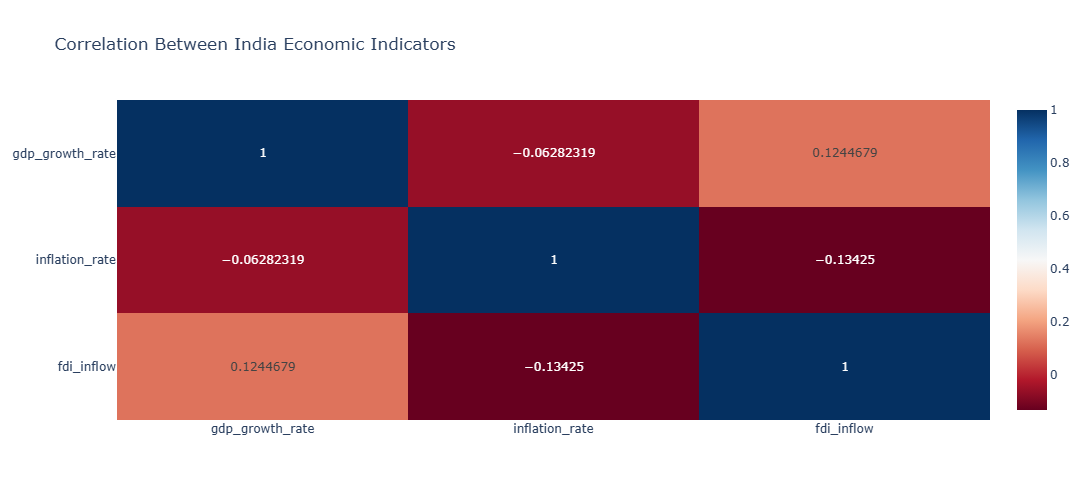


Correlation values:
                 gdp_growth_rate  inflation_rate  fdi_inflow
gdp_growth_rate         1.000000       -0.062823    0.124468
inflation_rate         -0.062823        1.000000   -0.134250
fdi_inflow              0.124468       -0.134250    1.000000


In [8]:
correlation = df[['gdp_growth_rate', 'inflation_rate', 'fdi_inflow']].corr()

fig = px.imshow(
    correlation,
    title='Correlation Between India Economic Indicators',
    color_continuous_scale='RdBu',
    aspect='auto',
    text_auto=True
)

fig.update_layout(
    width=600,
    height=500
)

fig.show()

print("\nCorrelation values:")
print(correlation)

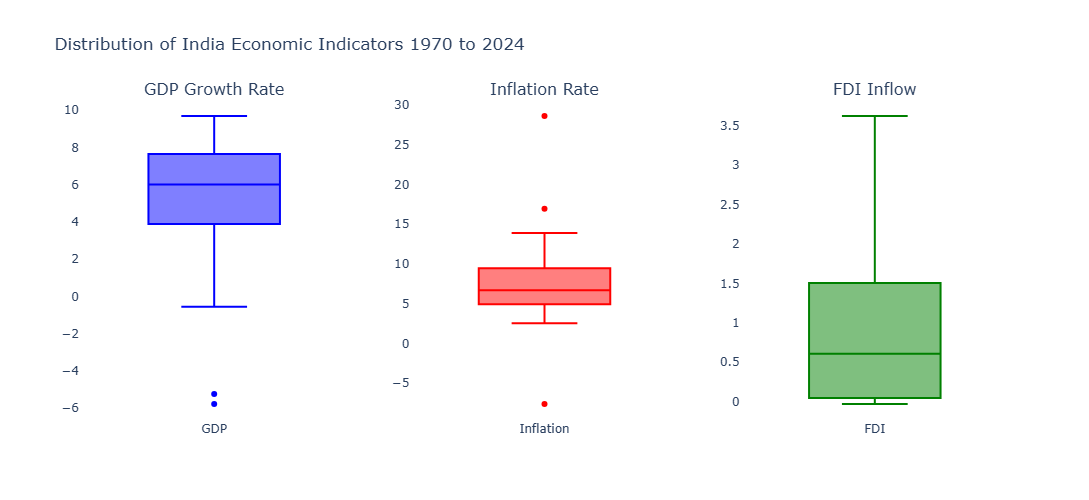

In [9]:
fig = make_subplots(rows=1, cols=3,
    subplot_titles=(
        'GDP Growth Rate',
        'Inflation Rate',
        'FDI Inflow'
    )
)

fig.add_trace(
    go.Box(y=df['gdp_growth_rate'],
    name='GDP', marker_color='blue'),
    row=1, col=1
)

fig.add_trace(
    go.Box(y=df['inflation_rate'],
    name='Inflation', marker_color='red'),
    row=1, col=2
)

fig.add_trace(
    go.Box(y=df['fdi_inflow'],
    name='FDI', marker_color='green'),
    row=1, col=3
)

fig.update_layout(
    height=500,
    title_text='Distribution of India Economic Indicators 1970 to 2024',
    plot_bgcolor='white',
    showlegend=False
)

fig.show()